In [2]:
import numpy as np 
import pyvista 
from tqdm import tqdm 
import glob 
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import griddata 

import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000000000000000000
import matplotlib.pyplot as plt 
from matplotlib.cm import ScalarMappable



/home/jonas/.local/lib/python3.8/site-packages/pyvista/jupyter/notebook.py:60: UserWarning: Failed to use notebook backend: 

Please install `ipyvtklink` to use this feature: https://github.com/Kitware/ipyvtklink

Falling back to a static output.
  warnings.warn(


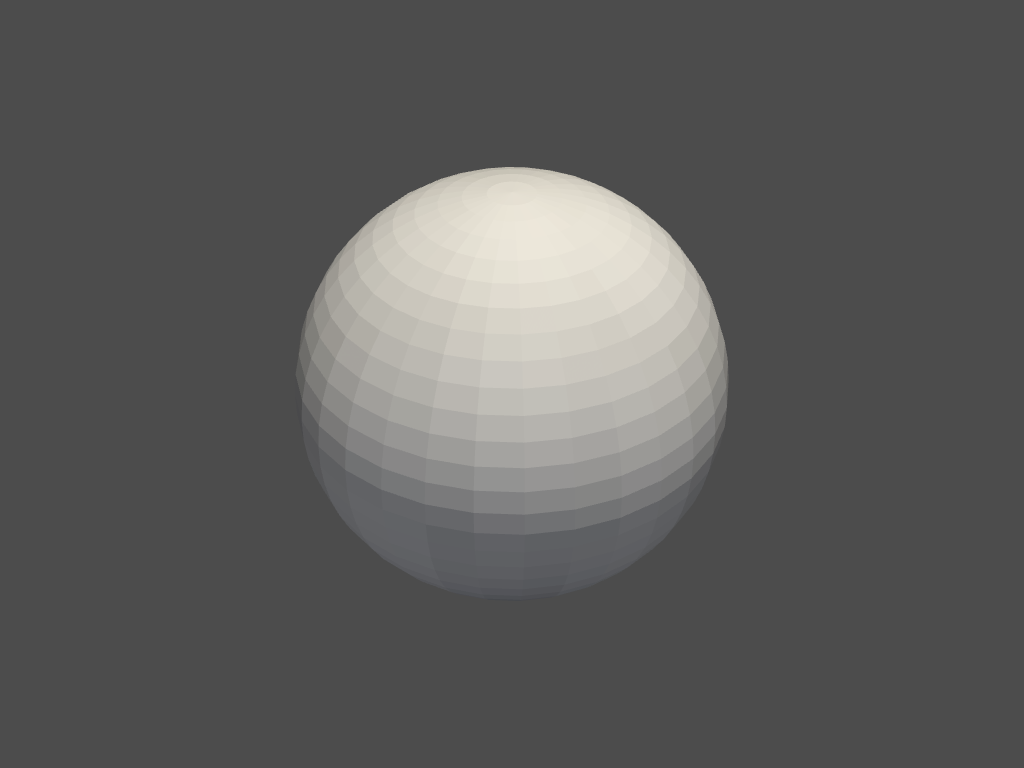

In [1]:
import pyvista as pv

mesh = pv.Sphere()

# Create a Plotter with off_screen=True to avoid opening a window
plotter = pv.Plotter(off_screen=True)
plotter.add_mesh(mesh)
plotter.show(auto_close=False)  # Render the scene but don’t close immediately

# Save screenshot to file
plotter.screenshot("output_image.png")

# Close the plotter explicitly
plotter.close()


In [59]:
data = {}
xi = np.linspace(0,1,1001)
yi = np.linspace(0,1,1001)
data['X'], data['Y'] = np.meshgrid(xi, yi)

for sc in scenarios: 
    print(sc)
    data[sc] = {}
    for time in times:
        print(time) 
        data[sc][time] = griddata((x, y), rawdata[sc][time], (data['X'], data['Y']), method='linear')
    print('alpha')
    data[sc]['alpha'] = griddata((x, y), rawdata[sc]["alpha"], (data['X'], data['Y']), method='linear')

0
1.0
2.0
3.0
alpha
1
1.0
2.0
3.0
alpha
2
1.0
2.0
3.0
alpha


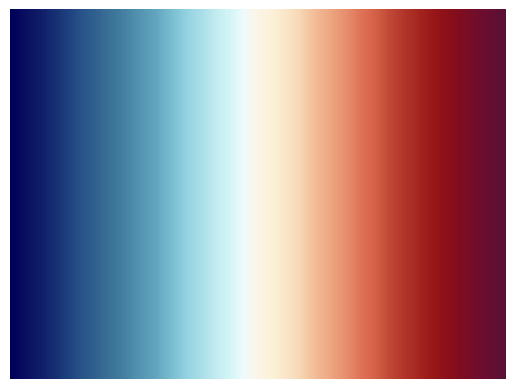

In [60]:
cooltowarmcolors = [
    (0.000000, 0.000000, 0.349020), 
    (0.039216, 0.062745, 0.380392), 
    (0.062745, 0.117647, 0.411765), 
    (0.090196, 0.184314, 0.450980), 
    (0.125490, 0.262745, 0.501961), 
    (0.160784, 0.337255, 0.541176), 
    (0.200000, 0.396078, 0.568627),      
    (0.239216, 0.454902, 0.600000),
    (0.286275, 0.521569, 0.650980),
    (0.337255, 0.592157, 0.701961),
    (0.388235, 0.654902, 0.749020),
    (0.466667, 0.737255, 0.819608),
    (0.572549, 0.819608, 0.878431),
    (0.654902, 0.866667, 0.909804),
    (0.752941, 0.917647, 0.941176),
    (0.823529, 0.956863, 0.968627),
    (0.941176, 0.984314, 0.988235),
    (0.988235, 0.960784, 0.901961),
    (0.988235, 0.945098, 0.850980),
    (0.980392, 0.898039, 0.784314),
    (0.968627, 0.835294, 0.698039),
    (0.949020, 0.733333, 0.588235),
    (0.929412, 0.650980, 0.509804),
    (0.909804, 0.564706, 0.435294),
    (0.878431, 0.458824, 0.352941),
    (0.839216, 0.388235, 0.286275),
    (0.760784, 0.294118, 0.211765),
    (0.701961, 0.211765, 0.168627),
    (0.650980, 0.156863, 0.129412),
    (0.600000, 0.094118, 0.094118),
    (0.549020, 0.066667, 0.098039),
    (0.501961, 0.050980, 0.125490),
    (0.450980, 0.052902, 0.172549),
    (0.400000, 0.054902, 0.192157),
    (0.349020, 0.070588, 0.211765)
]

# Create sample colormaps for demo
cooltowarmcmap = LinearSegmentedColormap.from_list("cooltowarm", cooltowarmcolors)

gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.imshow(gradient, aspect='auto', cmap=cooltowarmcmap)
plt.axis('off')
plt.show()

In [76]:
for sc in [0,1,2]: 
    print(sc, np.min(data[sc]['alpha']), np.max(data[sc]['alpha']))

vmin = {}
vmax = {}
vabs = {}
for time in ['alpha', 1.0,2.0,3.0]: 
    vmin[time] = np.min([np.min(data[0][time]), np.min(data[1][time]), np.min(data[2][time])])
    vmax[time] = np.max([np.max(data[0][time]), np.max(data[1][time]), np.max(data[2][time])])
    vabs[time] = np.max([np.abs(vmin[time]), np.abs(vmax[time])])
    print(vmin[time], vmax[time], vabs[time])



0 1.021179062499999 1.971806984863281
1 1.0 2.0
2 0.9999999999999998 2.000000000000001
0.9999999999999998 2.000000000000001 2.000000000000001
-0.027760807918549416 0.11623825136881864 0.11623825136881864
-0.02497363593359471 0.07888265255432839 0.07888265255432839
-0.09547006417441911 1.3887943864964021e-11 0.09547006417441911


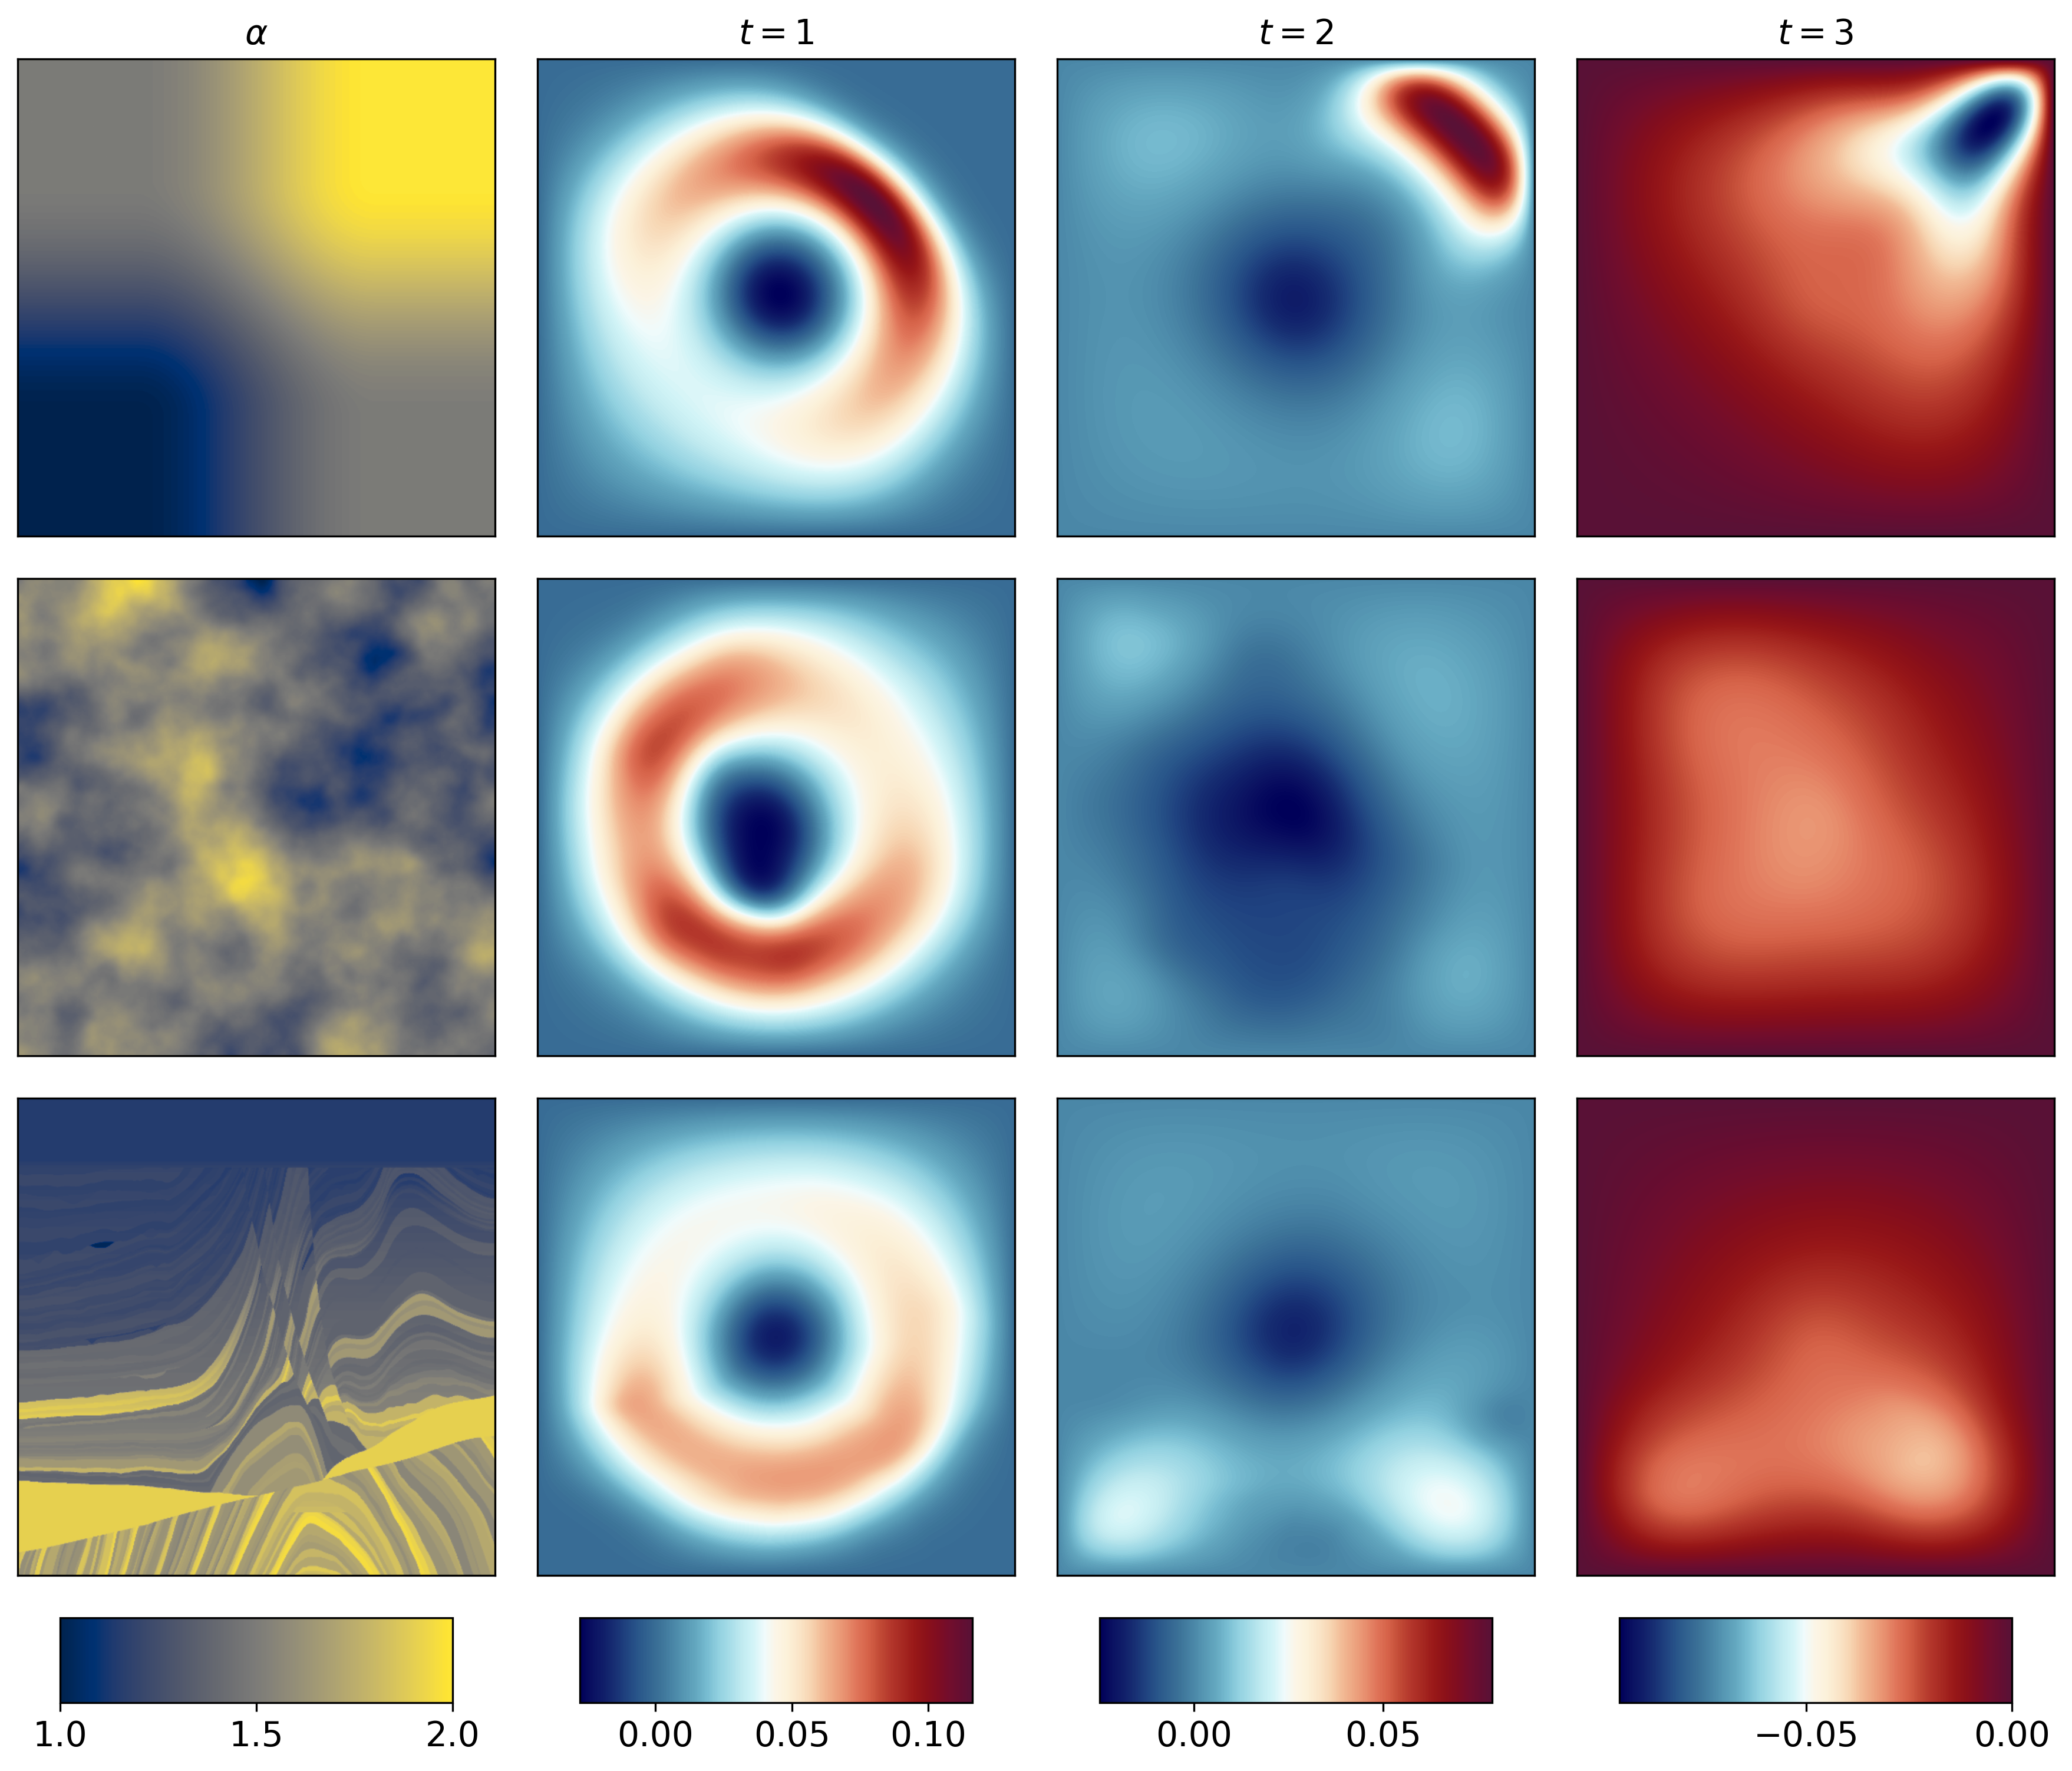

In [ ]:
mpl.rcParams['agg.path.chunksize'] = 10000000000000000000

fig = mpl.pyplot.figure(figsize = (12,12), dpi=300)

gap = 0.02 
width = 0.225 
cb_gap = 0.02

cmaps = {}
cmaps['alpha'] = 'cividis'
cmaps[1.0] = cooltowarmcmap
cmaps[2.0] = cooltowarmcmap
cmaps[3.0] = cooltowarmcmap

titles = {}
titles['alpha'] = r"$c_\alpha$"
titles[1.0] = r"$t = 1$"
titles[2.0] = r"$t = 2$"
titles[3.0] = r"$t = 3$"

cbtitles = {}
cbtitles['alpha'] = r"$c_\alpha$"
cbtitles[1.0] = r"$t = 1$"
cbtitles[2.0] = r"$t = 2$"
cbtitles[3.0] = r"$t = 3$"

ax = {}
ax['colorbar'] = {}
for idt, time in enumerate(['alpha'] + times): 
    ax['colorbar'][time] = fig.add_axes([0.05 + gap + cb_gap + (idt) * (gap + width), gap, width - 2*cb_gap, 0.04])   
    ax['colorbar'][time].set_xticks([]) 
    ax['colorbar'][time].set_yticks([]) 

for sc in [0,1,2]: 
    ax[sc] = {}
    for idt, time in enumerate(['alpha'] + times): 
        ax[sc][time] = fig.add_axes([0.05 + gap + (idt) * (gap + width), 0.08 + sc * (gap+width), width, width])    
        ax[sc][time].set_xticks([]) 
        ax[sc][time].set_yticks([]) 
        ax[sc][time].set_aspect('equal')

cnt = {} 
for sc in [0,1,2]: 
    cnt[sc] = {}
    for time in (['alpha'] + times):  
        cnt[sc][time] = ax[sc][time].imshow(data[sc][time][::-1], cmap = cmaps[time], vmin=vmin[time], vmax=vmax[time])

for time in (['alpha'] + times):  
    norm = mpl.colors.Normalize(vmin=vmin[time], vmax=vmax[time])
    sm = ScalarMappable(norm=norm, cmap=cmaps[time])
    sm.set_array([])  # Dummy data to satisfy colorbar
    cbar = fig.colorbar(sm, cax=ax['colorbar'][time], orientation='horizontal')
    cbar.ax.tick_params(labelsize=14)

for time in (['alpha'] + times):  
    ax['colorbar'][time].set_title(cbtitles[time], fontsize=14)
    ax[2][time].set_title(titles[time], fontsize=14)

fig.savefig("SpaceDependentMarmousi.png", bbox_inches='tight', pad_inches=0.3)
fig.savefig("SpaceDependentMarmousi.pdf", bbox_inches='tight', pad_inches=0.3)
